# Visualize Multimodal Embeddings

Fetch all vectors from Qdrant, reduce to 2D with t-SNE, and plot clusters colored by modality.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from qdrant_client import QdrantClient

from app.config import get_settings

In [2]:
settings = get_settings()
client = QdrantClient(host=settings.qdrant_host, port=settings.qdrant_port)

# Fetch all points from the collection
result = client.scroll(
    collection_name=settings.collection_name,
    with_vectors=True,
    limit=1000,
)
points = result[0]
print(f"Fetched {len(points)} vectors")

Fetched 8 vectors


In [3]:
vectors = np.array([p.vector for p in points])
modalities = [p.payload.get("modality", "unknown") for p in points]
labels = [p.payload.get("source", "") for p in points]

print(f"Vector shape: {vectors.shape}")
print(f"Modalities: {set(modalities)}")

Vector shape: (8, 3072)
Modalities: {'pdf', 'text', 'audio', 'image', 'video'}


In [ ]:
# Reduce to 2D with t-SNE
perplexity = min(max(5, len(vectors) // 4), len(vectors) - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
coords = tsne.fit_transform(vectors)
print(f"t-SNE output shape: {coords.shape}")
print(f"Perplexity used: {perplexity}")

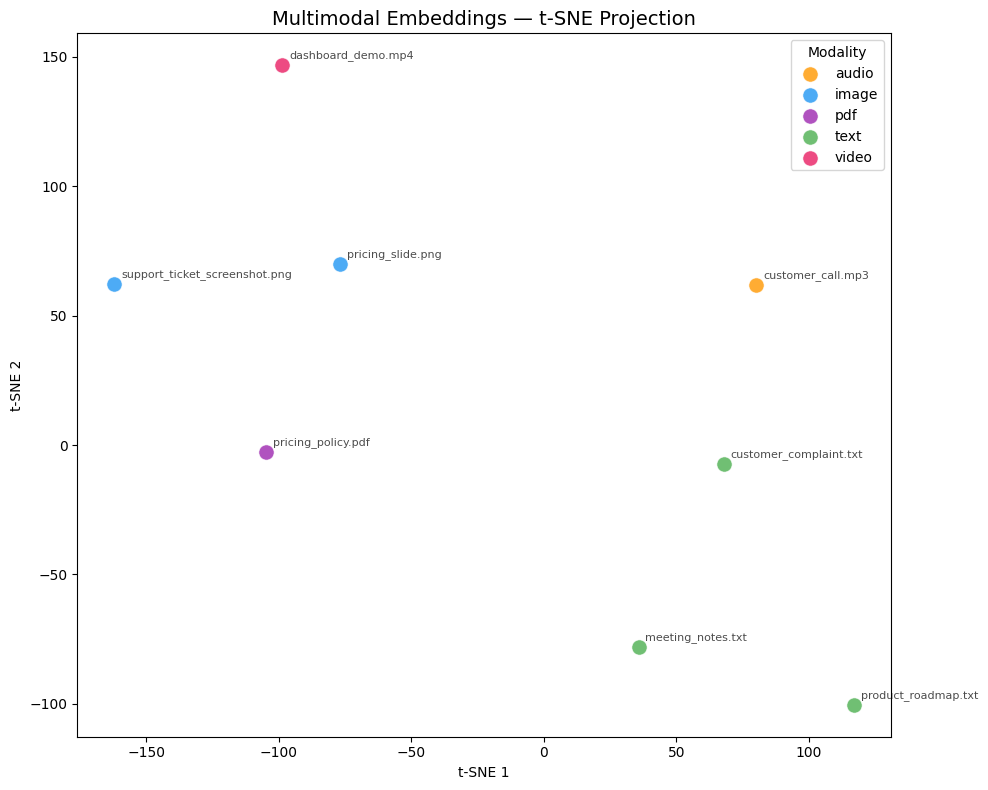

In [5]:
COLORS = {
    "text": "#4CAF50",
    "image": "#2196F3",
    "audio": "#FF9800",
    "video": "#E91E63",
    "pdf": "#9C27B0",
}

fig, ax = plt.subplots(figsize=(10, 8))

for mod in sorted(set(modalities)):
    mask = [m == mod for m in modalities]
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=COLORS.get(mod, "gray"),
        label=mod,
        s=120,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
    )

# Add file name labels
for i, label in enumerate(labels):
    ax.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_title("Multimodal Embeddings — t-SNE Projection", fontsize=14)
ax.legend(title="Modality", fontsize=10)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

In [ ]:
# --- Infer theme from source filename + description ---
THEME_KEYWORDS = {
    "pricing_complaint": [
        "pricing", "price", "churn", "complaint", "globex", "invoice",
        "discount", "roadmap", "enterprise legacy", "billing", "dashboard_demo",
    ],
    "onboarding": [
        "onboarding", "kickoff", "setup", "api key", "sso", "training",
        "initech", "checklist", "walkthrough", "welcome",
    ],
    "security_incident": [
        "security", "breach", "vulnerability", "patch", "cve", "incident",
        "unauthorized", "audit", "remediation",
    ],
    "product_launch": [
        "launch", "insights ai", "beta", "whitepaper", "demo_narration",
        "anomaly detection", "product_demo", "insights_ai",
    ],
    "hiring_culture": [
        "hiring", "team", "culture", "interview", "remote", "diversity",
        "handbook", "retrospective", "office_tour", "growth_chart",
        "employee", "retro",
    ],
}

THEME_COLORS = {
    "pricing_complaint": "#FF5722",
    "onboarding": "#4CAF50",
    "security_incident": "#F44336",
    "product_launch": "#7C4DFF",
    "hiring_culture": "#FFB300",
    "unknown": "#9E9E9E",
}


def infer_theme(source: str, description: str) -> str:
    """Match a point to a theme using keyword matching on source + description."""
    text = f"{source} {description}".lower()
    best_theme = "unknown"
    best_score = 0
    for theme, keywords in THEME_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw in text)
        if score > best_score:
            best_score = score
            best_theme = theme
    return best_theme


descriptions = [p.payload.get("description", "") for p in points]
themes = [infer_theme(src, desc) for src, desc in zip(labels, descriptions)]
print(f"Themes detected: {dict(sorted({t: themes.count(t) for t in set(themes)}.items()))}")

# --- Theme-colored scatter plot ---
fig, ax = plt.subplots(figsize=(10, 8))

for theme in sorted(set(themes)):
    mask = [t == theme for t in themes]
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=THEME_COLORS.get(theme, "gray"),
        label=theme.replace("_", " ").title(),
        s=120,
        alpha=0.8,
        edgecolors="white",
        linewidth=0.5,
    )

for i, label in enumerate(labels):
    ax.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        fontsize=7,
        alpha=0.6,
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_title("Multimodal Embeddings — Colored by Semantic Theme", fontsize=14)
ax.legend(title="Theme", fontsize=10)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()